# 3W Toolkit

**Version:** 3.0.0  

**Authors:**
<style>
.icon-bullet li {
    list-style-type: none;
    position: relative;
    padding-left: 15px;
}
.icon-bullet li:before {
    content: "►";
    position: absolute;
    left: 0;
    color: #2c3e50;
    font-size: 12px;
}
</style>

<div style="column-count: 4;" class="icon-bullet">
<li> Bruno Coelho Martins
<li> Carla Pagliari
<li> Eduardo A. B. Silva
<li> Eduardo Henrique
<li> Fernanda Duarte Vilela Reis de Oliveira
<li> Gabriel Henrique Braga Lisboa
<li> Luiza Helena de Andrade Leite
<li> Marcello Campos
<li> Matheus Ferreira Espirito Santo
<li> Matheus Ramos Parracho
<li> Natanael Moura Junior
<li> Pedro Braga Lisboa
<li> Rafael Padilla
<li> Sergio Lima Netto
<li> Thadeu Luiz Barbosa Dias
<li> Umberto Augusto
</div>

**Description:** Demonstrative notebook with the main functions of *3W Toolkit*.

----

## Table of Contents 📑

1. 🚀 [Introduction to 3WToolkit](#intro)<br>
   1.1. [Installation with `pip install`](#11-installation-with-pip-install)<br> 
   1.2. [Cloning & Installing](#12-cloning--installing)<br> 
   1.3. [Forking & Installing](#13-forking--installing)<br><br> 
2. 📂 [Dataset 3W](#dataset-3w)<br>
   2.1. [Loading the Dataset](#21-loading-the-dataset)<br> 
   2.2. [Filtering & Exploring the Data](#22-filtering--exploring-the-data)<br><br>
3. ⚙️ [Preprocessing](#preprocessing)<br>
   3.1. [Cleaning the dataset](#31-cleaning-the-dataset)<br>
   3.2. [Handling missing values (Imputation)](#32-handling-missing-values-imputation)<br> 
   3.3. [Normalization](#33-normalization)<br> 
   3.4. [Renaming columns](#34-renaming-columns)<br>
   3.5. [Building preprocessing pipeline](#35-building-preproc-pipeline)<br><br> 
4. 🔎 [Feature Extraction](#feature-extraction)<br>
   4.1. [Custom Feature Extraction pipeline](#41-custom-feature-extraction-pipelines)<br>
   4.2. [Windowing](#42-windowing)<br> 
   4.3. [Statistical Feature Extraction](#43-statistical-feature-extraction)<br> 
   4.4. [Wavelet Feature Extraction](#44-wavelet-feature-extraction)<br> 
   4.5. [Exponentially Weighted Statistical Feature Extraction](#45-exponentially-weighted-statistical-feature-extraction)<br><br> 
5. 📊 [Exploratory Analysis](#exploratory-analysis)<br> 
   5.1. [Visualization Tools](#51-visualization-tools)<br><br> 
6. 🤖 [Model Training and Evaluation](#model-training-and-evaluation)<br><br>
7. 🔗 [Pipeline Integration](#pipeline-integration)<br><br>
8. 📄 [Report Generation](#report-generation)<br>

----

## 🚀 1. Introduction to 3WToolkit <a id="intro"></a>


The **3WToolkit** is a **modular** and **open-source Artificial Intelligence (AI) toolkit** for **time series processing**, designed for **fault detection and classification** in the operation of **oil wells**.

Based on the experience with the original **3W Toolkit** system and using the [**3W dataset from Petrobras**](https://github.com/petrobras/3W/), the 3W Toolkit offers enhanced features such as:

- **Advanced data imputation**
- **Deep feature extraction**
- **Synthetic data augmentation**
- **High-performance computing capabilities** for model training

Please find bellow different ways to install the **3WToolkit** project hosted on GitHub: https://github.com/petrobras/3W.

------

### 1.1. Installation with `pip install` <a id="11-installation-with-pip-install"></a>

```bash
pip install git+https://github.com/petrobras/3W.git
```

------

### 1.2. Cloning and installing <a id="12-cloning--installing"></a>

First, clone the repository and navigate into the project directory:

```bash
git clone https://github.com/petrobras/3W.git
cd 3W
```

Next, install the project in editable (development) mode. This allows you to modify the source code and have the changes reflected immediately without reinstalling the package.

<br>
You can choose between two installation methods: <br><br>

**Option A: Using pip (standard approach)**

Recommended if you are already familiar with Python virtual environments and `pip`.

```bash
pip install -e .
```
<br>

**Option B: Using uv (faster and modern alternative)**

`uv` is a fast Python package manager and environment tool. It can create and manage virtual environments as well as install dependencies efficiently.

```bash
uv venv .venv
source .venv/bin/activate  # On Windows use: .venv\Scripts\activate
uv pip install -e .
```

<br>

> **Note:** The `-e` flag installs the project in editable mode, which is especially useful for development and contributing via pull requests.

------

### 1.3. Forking and installing <a id="13-forking--installing"></a>

If you plan to contribute to the project, you should fork the repository instead of cloning it directly. This allows you to make changes in your own copy and later submit them via pull requests.

<br>
<strong>I. Fork the repository on <a href=https://github.com/petrobras/3W> GitHub</a> (click the <strong>Fork</strong> button).</strong>

<p align="center">
  <img src="../../images/forking_the_repo.jpg" alt="Forking the repo" width="800"/>
</p>

<strong>II. Clone your forked project</strong>:

After forking, your GitHub account will contain a copy of the repository.  
Run the commands below, replacing `<YOUR-USERNAME>` with your GitHub username:

```bash
git clone https://github.com/<YOUR-USERNAME>/3W.git
cd 3W

------

### Imports

In this section, we import the required libraries and modules used throughout the tutorial.

We rely on common scientific Python packages for data manipulation and visualization, along with the `ThreeWToolkit` components for dataset handling, preprocessing, feature extraction, and visualization.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ThreeWToolkit.dataset import ParquetDatasetConfig, TransformConfig

from ThreeWToolkit.preprocessing import (
    ImputeMissingConfig,
    NormalizeConfig,
    RenameColumnsConfig,
    CleanSignalsConfig,
    FillLabelsConfig,
    RemapClassConfig,
    SequentialPreprocessingAdapterConfig,
)
from ThreeWToolkit.feature_extraction import (
    WindowingConfig,
    StatisticalConfig,
    WaveletConfig,
    EWStatisticalConfig,
    SequentialFeatureAdapterConfig,
    ConcatFeatureAdapterConfig
)

from ThreeWToolkit.data_visualization import DataVisualization

from ThreeWToolkit.models import MLPConfig

from ThreeWToolkit.trainer import TorchTrainerConfig
   
from ThreeWToolkit.assessment import ModelAssessmentConfig

-----

## 📂 2. Dataset 3W <a id="dataset-3w"></a>

* **Format**: Tabular, split into files in parquet format
* **Hosted** on: 3W Dataset - Figshare
* **Size**: 1.67 GB
* **Splits**: 10 folders with parquet files, one folder for each event.
* **License** & Usage: Apache 2.0

**Define path**

Here we define the path to the dataset directory. This path should point to the location where the dataset is stored on your machine.

In [3]:
dataset_path = "../../dataset"

Make sure the directory structure matches the expected format of the project. If your dataset is located elsewhere, update the path accordingly.

> **Tip:** You can also use absolute paths if you prefer, but relative paths make the project more portable across different environments.


### 2.1. Loading the Dataset <a id="21-loading-the-dataset"></a>

Let’s load the dataset using the `ThreeWToolkit` library.

We create a dataset configuration pointing to the dataset path and then build the dataset object:

In [4]:
# Create and load
ds = ParquetDatasetConfig(path=dataset_path).build()

2026-04-22 23:41:46,135 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-22 23:41:46,136 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-22 23:41:46,139 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


The `ParquetDatasetConfig` class is responsible for reading the dataset from disk and preparing it for further processing.

* `path`: Directory where the dataset is stored.
* `.build()`: Instantiates and loads the dataset.

> **Note:** Make sure the dataset has been downloaded and extracted to the specified `dataset_path` before running this step. Otherwise, use the `force_download` argument to download the dataset locally.
```

### 2.2. Filtering & Exploring the Data <a id="22-filtering--exploring-the-data"></a>

In this section, we explore the structure of the dataset and inspect its contents.

First, let’s check how many events are available:

Calling `len(ds)` returns the number of samples available in the dataset.

In [5]:
# Count events
total_events = len(ds)
print(f"Total events: {total_events}")

Total events: 2228


Each element in the dataset represents an **event**, which is an object containing the following fields:

* `signal`: the time-series data
* `label`: the class or annotation associated with the event
* `metadata`: additional information about the event

Let’s inspect the structure of a single event:


In [6]:
event_id = 1200
event = ds[event_id]

print(f"Event type: {type(event)}")

Event type: <class 'ThreeWToolkit.core.dataset_outputs.DatasetOutputs'>


We can also list the available fields in the event object:

In [7]:
print("Available fields:", list(event.__class__.model_fields.keys()))

Available fields: ['signal', 'label', 'metadata']


Now, let’s take a closer look at the signal:

In [8]:
signal = event.signal

print(f"Signal type: {type(signal)}")
print(f"Signal shape: {np.shape(signal)}")

Signal type: <class 'pandas.core.frame.DataFrame'>
Signal shape: (10653, 28)


In [9]:
# Show a small preview
print("Signal preview:")
signal[:5]

Signal preview:


,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,P-PDG,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,state
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-09-17 03:02:28,100.0,42.80884,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,...,23373210.0,NaN,13690090.0,NaN,1.046690,37.97378,NaN,61.74433,56.71452,<NA>
2017-09-17 03:02:29,100.0,42.80884,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,...,23373360.0,NaN,13690150.0,NaN,1.053131,37.97408,NaN,61.74434,56.71438,<NA>
2017-09-17 03:02:30,100.0,42.80884,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,...,23373500.0,NaN,13690200.0,NaN,1.059572,37.97438,NaN,61.74434,56.71424,<NA>
2017-09-17 03:02:31,100.0,42.80885,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,...,23373640.0,NaN,13690390.0,NaN,1.066013,37.97467,NaN,61.74434,56.71406,<NA>
2017-09-17 03:02:32,100.0,42.80885,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,...,23373780.0,NaN,13690580.0,NaN,1.072454,37.97498,NaN,61.74434,56.71388,<NA>


Next, we inspect the labels:

In [10]:
label = event.label

print(f"Label type: {type(label)}")
print(f"Label shape: {np.shape(label)}")

Label type: <class 'pandas.core.series.Series'>
Label shape: (10653,)


In [11]:
print("Unique label values:")
print(np.unique(label))

Unique label values:
[ 4. nan]


In [12]:
print("Label preview:")
print(label[5000:5010])

Label preview:
timestamp
2017-09-17 04:25:48    4
2017-09-17 04:25:49    4
2017-09-17 04:25:50    4
2017-09-17 04:25:51    4
2017-09-17 04:25:52    4
2017-09-17 04:25:53    4
2017-09-17 04:25:54    4
2017-09-17 04:25:55    4
2017-09-17 04:25:56    4
2017-09-17 04:25:57    4
Name: class, dtype: Int16


Optionally, we can also inspect the metadata:

In [13]:
metadata = event.metadata

print("Metadata:")
print(metadata)

Metadata:
{'file_name': PosixPath('4/WELL-00014_20170917030228.parquet'), 'event_class': 4, 'event_type': 'real'}


**The dataset can be filtered and split using different criteria such as event type, event class, or a custom file list:**

#### Split by event type

We can filter the dataset by event type. Available options include: `real`, `drawn`, and `simulated`.

For example, selecting only **DRAWN** and **SIMULATED** events:

In [14]:
ds = ParquetDatasetConfig(
    path=dataset_path,
    event_type=["drawn", "simulated"]
).build()

print(f"\nFiltered dataset size: {len(ds)}")

2026-04-22 23:41:47,155 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-22 23:41:47,157 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-22 23:41:47,165 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!



Filtered dataset size: 1109


Now selecting only **REAL** events:

In [15]:
ds = ParquetDatasetConfig(
    path=dataset_path,
    event_type=["real"]
).build()

print(f"\nFiltered dataset size: {len(ds)}")

2026-04-22 23:41:47,644 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-22 23:41:47,646 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-22 23:41:47,649 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!



Filtered dataset size: 1119


> Any combination of `real`, `drawn`, and `simulated` is supported.

#### Split by event class

We can also filter the dataset based on event classes.

Selecting only events from class `0`:

In [16]:
target_class = [0]

ds = ParquetDatasetConfig(
    path=dataset_path,
    target_class=target_class
).build()

2026-04-22 23:41:48,098 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-22 23:41:48,100 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-22 23:41:48,103 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


In [17]:
print(f"Filtered dataset size: {len(ds)}")
print("Unique labels:", np.unique(ds[0].label))

Filtered dataset size: 594
Unique labels: [ 0. nan]


Selecting only class `2`:

In [18]:
target_class = [2]

ds = ParquetDatasetConfig(
    path=dataset_path,
    target_class=target_class
).build()

2026-04-22 23:41:48,752 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-22 23:41:48,754 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-22 23:41:48,759 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


In [19]:
print(f"Filtered dataset size: {len(ds)}")
print("Unique labels:", np.unique(ds[0].label))

Filtered dataset size: 38
Unique labels: [  0   2 102]


Selecting multiple classes:

In [20]:
target_class = [0, 2]

ds = ParquetDatasetConfig(
    path=dataset_path,
    target_class=target_class
).build()

2026-04-22 23:41:49,398 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-22 23:41:49,399 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-22 23:41:49,402 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


In [21]:
print(f"Filtered dataset size: {len(ds)}")

Filtered dataset size: 632


**Combining filters**

It is also possible to combine filters. For example, selecting only **REAL** events from class `2`:

In [22]:
target_class = [2]

ds = ParquetDatasetConfig(
    path=dataset_path,
    event_type=["real"],
    target_class=target_class
).build()

2026-04-22 23:41:49,959 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-22 23:41:49,962 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-22 23:41:49,969 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


In [23]:
print(f"Filtered dataset size: {len(ds)}")
print("Unique labels:", np.unique(ds[0].label))

Filtered dataset size: 22
Unique labels: [  0.   2. 102.  nan]


#### Split using a file list

Another flexible approach is to define a custom split using a list of file paths.

This is especially useful for creating train/test splits.

Example of a file list (paths relative to the dataset root):

In [24]:
my_split = [
    "./0/WELL-00008_20170817140222.parquet",
    "./3/SIMULATED_00061.parquet",
    "./4/WELL-00004_20140806090103.parquet",
    "./6/SIMULATED_00117.parquet",
    "./0/WELL-00001_20170201110124.parquet",
    "./5/SIMULATED_00138.parquet",
    "./4/WELL-00005_20170624070158.parquet",
    "./8/SIMULATED_00044.parquet",
    "./5/SIMULATED_00303.parquet",
    "./9/SIMULATED_00028.parquet",
    "./8/SIMULATED_00072.parquet",
    "./7/WELL-00022_20180802233838.parquet",
    "./0/WELL-00003_20170812110000.parquet",
    "./9/SIMULATED_00115.parquet",
    "./1/SIMULATED_00025.parquet",
    "./9/SIMULATED_00065.parquet",
    "./6/SIMULATED_00041.parquet",
    "./5/SIMULATED_00329.parquet",
    "./4/WELL-00004_20141118160016.parquet",
    "./6/SIMULATED_00095.parquet",
]

print(f"Number of files in split: {len(my_split)}")

Number of files in split: 20


Now, load only the selected files:

In [25]:
ds = ParquetDatasetConfig(
    path=dataset_path,
    split="list",
    file_list=my_split
).build()

2026-04-22 23:41:50,622 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-22 23:41:50,624 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-22 23:41:50,629 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


In [26]:
print(f"Filtered dataset size: {len(ds)}")

Filtered dataset size: 20


In [27]:
# Inspect one sample
print("Sample label:", ds[2].label)

Sample label: timestamp
2014-08-06 09:01:03    <NA>
2014-08-06 09:01:04    <NA>
2014-08-06 09:01:05    <NA>
2014-08-06 09:01:06    <NA>
2014-08-06 09:01:07    <NA>
                       ... 
2014-08-06 11:59:56       4
2014-08-06 11:59:57       4
2014-08-06 11:59:58       4
2014-08-06 11:59:59       4
2014-08-06 12:00:00       4
Name: class, Length: 10738, dtype: Int16


> **Tip:** You can store the file list in a `.txt` file and load it dynamically, which is useful for reproducible experiments.

--------

## 3. ⚙️ Preprocessing <a id="preprocessing"></a>

Preprocessing is an essential step to prepare the dataset before training or evaluating models.  
The 3W Toolkit provides utility classes to handle missing values, normalize data, clean signals, and rename columns.

In this section, we demonstrate the usage of:

- `ImputeMissing` → Fill missing values using different strategies  
- `Normalize` → Apply L1, L2, or max normalization  
- `RenameColumns` → Rename DataFrame columns using a mapping dictionary  
- `CleanSignals` → Identify frozen / out-of-range signals using IQR thresholds  
- `FillLabels` → Fill missing values in labels  
- `RemapClass` → Remap target classes into a sequential format  

**Inspecting a sample event**

First, we select a single event from the dataset and inspect its signal:

In [28]:
event_id = 2
event = ds[event_id]

print("Signal preview:")
event.signal.head()

Signal preview:


,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,P-PDG,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,state
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-08-06 09:01:03,0.0,29.57999,1.0,1.0,0.0,0.0,NaN,NaN,1.0,0.0,...,0.0,NaN,17773410.0,NaN,NaN,68.95986,NaN,90.0,106.5635,<NA>
2014-08-06 09:01:04,0.0,29.58001,1.0,1.0,0.0,0.0,NaN,NaN,1.0,0.0,...,0.0,NaN,17774250.0,NaN,NaN,68.97000,NaN,90.0,106.5635,<NA>
2014-08-06 09:01:05,0.0,29.58003,1.0,1.0,0.0,0.0,NaN,NaN,1.0,0.0,...,0.0,NaN,17775080.0,NaN,NaN,68.98015,NaN,90.0,106.5635,<NA>
2014-08-06 09:01:06,0.0,29.58006,1.0,1.0,0.0,0.0,NaN,NaN,1.0,0.0,...,0.0,NaN,17775920.0,NaN,NaN,68.96131,NaN,90.0,106.5635,<NA>
2014-08-06 09:01:07,0.0,29.58008,1.0,1.0,0.0,0.0,NaN,NaN,1.0,0.0,...,0.0,NaN,17776750.0,NaN,NaN,68.94247,NaN,90.0,106.5635,<NA>


### 3.1. Cleaning the dataset <a id="31-cleaning-the-dataset"></a>

Some signals may contain invalid values (e.g., frozen or out-of-range behavior).
The toolkit provides utilities to clean these signals.

We also introduce the **SequentialPreprocessingAdapterConfig**, which allows chaining multiple preprocessing steps into a pipeline.

**Key concepts:**

* Uses **IQR-based thresholds** to detect anomalies in signal statistics
* Signals outside thresholds may be replaced with `NaN`
* Lower thresholds → stricter filtering
* Higher thresholds → more lenient filtering
* Columns with too many missing values can be dropped (`missing_columns_threshold`)
* Designed for **continuous signals** (not categorical)

In [29]:
ds = ParquetDatasetConfig(path=dataset_path).build()

print(f"\nNumber of columns before cleaning: {ds[0].signal.shape[1]}")
print("Columns before cleaning:")
print(ds[0].signal.columns.tolist())

2026-04-22 23:41:51,277 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-22 23:41:51,278 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-22 23:41:51,282 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!



Number of columns before cleaning: 28
Columns before cleaning:
['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'state']


In [30]:
clean_signal = CleanSignalsConfig()

transformer = TransformConfig(pre_processing=clean_signal).build()
transformer.fit(ds)
transformed_ds = transformer.transform(ds)

print(f"\nNumber of columns after cleaning: {transformed_ds[0].signal.shape[1]}")
print("Columns after cleaning:")
print(transformed_ds[0].signal.columns.tolist())


Number of columns after cleaning: 15
Columns after cleaning:
['ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-MON-CKP', 'P-PDG', 'P-TPT', 'T-JUS-CKP', 'T-TPT', 'state']


### 3.2. Handling missing values (Imputation) <a id="32-handling-missing-values-imputation"></a>

We can fill missing values using different strategies:

* `"mean"` → column mean
* `"median"` → column median
* `"constant"` → fixed value
* `"ffill"` → forward fill
* `"bfill"` → backward fill
* `"interpolate"` → interpolation

Inspecting an event before imputation:


In [31]:
print("Before imputation:")
ds[0].signal.head()

Before imputation:


,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,P-PDG,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,state
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-02-01 01:02:07,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.64463,NaN,0.0,119.0781,<NA>
2017-02-01 01:02:08,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.63828,NaN,0.0,119.0781,<NA>
2017-02-01 01:02:09,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.63194,NaN,0.0,119.0781,<NA>
2017-02-01 01:02:10,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.62558,NaN,0.0,119.0781,<NA>
2017-02-01 01:02:11,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.61923,NaN,0.0,119.0781,<NA>


Applying mean imputation:


In [32]:
clean_signal = CleanSignalsConfig()
impute_missing = ImputeMissingConfig(strategy="mean")

transformer = TransformConfig(
    pre_processing=SequentialPreprocessingAdapterConfig(
        steps=[clean_signal, impute_missing]
    )
).build()

transformer.fit(ds)
transformed_ds = transformer.transform(ds)

In [33]:
print("\nAfter mean imputation:")
transformed_ds[0].signal.head()


After mean imputation:


,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,ESTADO-XO,P-MON-CKP,P-PDG,P-TPT,T-JUS-CKP,T-TPT,state
timestamp,,,,,,,,,,,,,,,
2017-02-01 01:02:07,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1627884.0,2.173313e+07,10074540.0,84.64463,119.0781,0.107588
2017-02-01 01:02:08,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1633397.0,2.173313e+07,10074540.0,84.63828,119.0781,0.107588
2017-02-01 01:02:09,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1638909.0,2.173313e+07,10074540.0,84.63194,119.0781,0.107588
2017-02-01 01:02:10,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1644422.0,2.173313e+07,10074540.0,84.62558,119.0781,0.107588
2017-02-01 01:02:11,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1649934.0,2.173313e+07,10074540.0,84.61923,119.0781,0.107588


### 3.3. Normalization <a id="33-normalization"></a>

Normalization scales the data using one of the following norms:

* `"l1"` → sum of absolute values = 1
* `"l2"` → Euclidean norm = 1
* `"max"` → divide by maximum absolute value

Checking values before normalization:

In [34]:
print("Before normalization:")
ds[0].signal["T-TPT"].head(10)

Before normalization:


timestamp
2017-02-01 01:02:07    119.0781
2017-02-01 01:02:08    119.0781
2017-02-01 01:02:09    119.0781
2017-02-01 01:02:10    119.0781
2017-02-01 01:02:11    119.0781
2017-02-01 01:02:12    119.0781
2017-02-01 01:02:13    119.0781
2017-02-01 01:02:14    119.0781
2017-02-01 01:02:15    119.0781
2017-02-01 01:02:16    119.0781
Name: T-TPT, dtype: float64

Applying the normalization and checking results:

In [35]:
normalize_step = NormalizeConfig(norm="l2")

transformer = TransformConfig(
    pre_processing=SequentialPreprocessingAdapterConfig(
        steps=[clean_signal, normalize_step]
    )
).build()

transformer.fit(ds)
transformed_ds = transformer.transform(ds)

In [36]:
print("\nAfter normalization:")
transformed_ds[0].signal["T-TPT"].head(10)


After normalization:


timestamp
2017-02-01 01:02:07    0.634582
2017-02-01 01:02:08    0.634582
2017-02-01 01:02:09    0.634582
2017-02-01 01:02:10    0.634582
2017-02-01 01:02:11    0.634582
2017-02-01 01:02:12    0.634582
2017-02-01 01:02:13    0.634582
2017-02-01 01:02:14    0.634582
2017-02-01 01:02:15    0.634582
2017-02-01 01:02:16    0.634582
Name: T-TPT, dtype: float64

### 3.4. Renaming columns <a id="34-renaming-columns"></a>

Function to rename columns of a DataFrame using a mapping dictionary  

The function accepts:  
- A dictionary (`columns_map`) where:  
  - Keys are the current column names  
  - Values are the new column names to assign  

Checking columns before renaming:

In [37]:
print("Before renaming:")
print(ds[0].signal.columns.tolist())

Before renaming:
['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'state']


Applying renaming and checking the changes:

In [38]:
columns_map = {
    "ABER-CKGL": "sensor_A",
    "ABER-CKP": "sensor_B"
}

rename_step = RenameColumnsConfig(columns_map=columns_map)

transformer = TransformConfig(pre_processing=rename_step).build()
transformer.fit(ds)
transformed_ds = transformer.transform(ds)

In [39]:
print("\nAfter renaming:")
print(transformed_ds[0].signal.columns.tolist())


After renaming:
['sensor_A', 'sensor_B', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'state']


### 3.5. Building preprocessing pipelines <a id="35-building-preproc-pipeline"></a>

One of the main advantages of the toolkit is the ability to combine multiple preprocessing steps into a single pipeline.

In [40]:
pipeline = SequentialPreprocessingAdapterConfig(
    steps=[
        CleanSignalsConfig(),
        ImputeMissingConfig(strategy="mean"),
        NormalizeConfig(norm="l2")
    ]
)

transformer = TransformConfig(pre_processing=pipeline).build()
transformer.fit(ds)
transformed_ds = transformer.transform(ds)

print("Pipeline applied successfully.")

Pipeline applied successfully.


> **Tip:** Using pipelines ensures consistency between training and inference, and makes experiments reproducible.

------

## 4. 🔎 Feature Extraction <a id="feature-extraction"></a>

In most time-series machine learning tasks, raw signal data is not used directly to train models.  
Instead, we perform **feature extraction**, which transforms segments (or *windows*) of the time-series into a set of informative features that better represent underlying patterns.

This process converts a sequence of data points into a structured feature vector that can be used by machine learning models.

---

### ⚠️ Important: Windowing comes first

All feature extractor classes in this toolkit operate on **pre-windowed data**.  
This means you **must first apply windowing** before extracting features.

The workflow is always:

1. **Windowing step** → split the signal into segments  
2. **Feature extraction step** → compute features for each window  


First, we select a subset of the dataset for feature extraction:

In [41]:
ds = ParquetDatasetConfig(
    path=dataset_path,
    event_type=["real"],
).build()

print(f"\nNumber of events in the dataset: {len(ds)}")

2026-04-23 00:12:26,416 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-23 00:12:26,418 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-23 00:12:26,428 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!



Number of events in the dataset: 1119


### 4.1. Custom feature extraction pipelines <a id="41-custom-feature-extraction-pipelines"></a>

To extract features using the `ThreeWToolkit`, we define transformation pipelines using:

* `TransformConfig`
* `SequentialFeatureAdapterConfig`
* `ConcatFeatureAdapterConfig`

These classes allow us to compose flexible and reusable feature extraction pipelines.

Using the **Transform** class, the *pipeline of feature extraction* can be defined like this: 

In [42]:
transformer = TransformConfig(
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            # Step 1: Windowing (required)
            WindowingConfig(),

            # Step 2: Feature extraction
            ConcatFeatureAdapterConfig(
                steps=[
                    StatisticalConfig(),
                    EWStatisticalConfig(),
                    WaveletConfig(),
                ]
            ),
        ]
    ),
).build()

**Explanation:**

* `WindowingConfig()` → splits the signal into fixed-size segments
* `StatisticalConfig()` → extracts statistical features (mean, std, etc.)
* `EWStatisticalConfig()` → extracts exponentially weighted statistics
* `WaveletConfig()` → extracts wavelet-based features
* `ConcatFeatureAdapterConfig` → concatenates all extracted features into a single vector

**Preprocessing before feature extraction**

Before applying feature extraction, we define a preprocessing pipeline to clean the data:

In [43]:
pre_processing_pipeline = SequentialPreprocessingAdapterConfig(
    steps=[
        CleanSignalsConfig(),
        ImputeMissingConfig(),
    ]
)

This ensures that:

* Invalid signals are cleaned
* Missing values are handled before feature computation

**Putting everything together**

Now we combine preprocessing and feature extraction into a single transformer:

In [44]:
transformer = TransformConfig(
    pre_processing=pre_processing_pipeline,
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(),
            ConcatFeatureAdapterConfig(
                steps=[
                    StatisticalConfig(),
                    EWStatisticalConfig(),
                    WaveletConfig(),
                ]
            ),
        ]
    ),
).build()

transformer.fit(ds)
transformed_ds = transformer.transform(ds)

print("Feature extraction completed.")

Feature extraction completed.


This pipeline-based approach makes it easy to:

* Reuse transformations
* Maintain consistency between training and inference
* Experiment with different feature combinations

In the next sections, we will explore each feature extraction method in more detail.

### 4.2. Windowing <a id="42-windowing"></a>

The `Windowing` step is responsible for splitting a 1D time-series into overlapping segments (*windows*).  
Each window represents a small portion of the signal and will later be used for feature extraction.

**Parameters:**
- `window` *(default="hann")*: Windowing function (e.g., `"hann"`, `"hamming"`)
- `window_size` *(default=4)*: Number of samples per window  
- `overlap` *(default=0.0)*: Overlap ratio between consecutive windows (`0 ≤ overlap < 1`)  
- `pad_last_window` *(default=False)*: Whether to pad the last window if incomplete  
- `pad_value` *(default=0.0)*: Value used for padding  

In [45]:
#### Example: Applying windowing

data_processor = TransformConfig(
    pre_processing=pre_processing_pipeline,
    feature_extraction=WindowingConfig(window_size=128),
).build()

data_processor.fit(ds)
transformed_data = data_processor.transform(ds)

single_event = transformed_data[0]

print(f"Windowed signal shape: {single_event.signal.shape}")
print("-" * 50)

print("Columns:")
print(single_event.signal.columns)
print("-" * 50)

print("Preview:")
print(single_event.signal.head())
print("-" * 50)

Windowed signal shape: (2688, 128)
--------------------------------------------------
Columns:
RangeIndex(start=0, stop=128, step=1)
--------------------------------------------------
Preview:
                      0    1    2    3    4    5    6    7    8    9    ...  \
window variable                                                         ...   
0      ESTADO-DHSV    1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  ...   
       ESTADO-M1      1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  ...   
       ESTADO-M2      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
       ESTADO-PXO     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
       ESTADO-SDV-GL  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

                      118  119  120  121  122  123  124  125  126  127  
window variable                                                         
0      ESTADO-DHSV    1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  
       ESTADO-M1      1.0  1.0  1.

> **Note:** After windowing, each row corresponds to a windowed segment of the original signal.

### 4.3. Statistical Feature Extraction <a id="43-statistical-feature-extraction"></a>

Statistical feature extraction is one of the most common approaches for time-series data.
The `StatisticalConfig` class computes descriptive statistics for each window, summarizing its distribution and behavior.

**Available features include:**

* **Central tendency & dispersion:** `mean`, `std`
* **Distribution shape:** `skew`, `kurtosis`
* **Range & quantiles:** `min`, `1qrt`, `med`, `3qrt`, `max`

In [46]:
#### Example: Windowing + Statistical features

windowing_config = WindowingConfig(window_size=128)

data_processor = TransformConfig(
    pre_processing=ImputeMissingConfig(),
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            windowing_config,
            StatisticalConfig(features=["mean", "std", "min", "max"]),
        ]
    ),
).build()

data_processor.fit(ds)
transformed_data = data_processor.transform(ds)

single_event = transformed_data[0]

print(f"Feature matrix shape: {single_event.signal.shape}")
print("-" * 50)

print("Feature columns:")
print(single_event.signal.columns)
print("-" * 50)

print("Preview:")
print("-" * 50)
single_event.signal.head()


Feature matrix shape: (168, 112)
--------------------------------------------------
Feature columns:
Index(['mean_ABER-CKGL', 'mean_ABER-CKP', 'mean_ESTADO-DHSV', 'mean_ESTADO-M1',
       'mean_ESTADO-M2', 'mean_ESTADO-PXO', 'mean_ESTADO-SDV-GL',
       'mean_ESTADO-SDV-P', 'mean_ESTADO-W1', 'mean_ESTADO-W2',
       ...
       'max_P-PDG', 'max_P-TPT', 'max_PT-P', 'max_QBS', 'max_QGL',
       'max_T-JUS-CKP', 'max_T-MON-CKP', 'max_T-PDG', 'max_T-TPT',
       'max_state'],
      dtype='object', length=112)
--------------------------------------------------
Preview:
--------------------------------------------------


,mean_ABER-CKGL,mean_ABER-CKP,mean_ESTADO-DHSV,mean_ESTADO-M1,mean_ESTADO-M2,mean_ESTADO-PXO,mean_ESTADO-SDV-GL,mean_ESTADO-SDV-P,mean_ESTADO-W1,mean_ESTADO-W2,...,max_P-PDG,max_P-TPT,max_PT-P,max_QBS,max_QGL,max_T-JUS-CKP,max_T-MON-CKP,max_T-PDG,max_T-TPT,max_state
window,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,10074540.0,0.0,0.0,0.0,84.64463,0.0,0.0,119.0781,0.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,10074540.0,0.0,0.0,0.0,85.05927,0.0,0.0,119.0786,0.0
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,10074540.0,0.0,0.0,0.0,85.30231,0.0,0.0,119.0792,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,10074540.0,0.0,0.0,0.0,84.68998,0.0,0.0,119.0798,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,10074540.0,0.0,0.0,0.0,84.54279,0.0,0.0,119.0804,0.0


**What is happening here:**

1. The signal is split into windows (`WindowingConfig`)
2. For each window, statistical features are computed
3. The output is a tabular representation where:

   * Each row = one window
   * Each column = one feature

This transformation is fundamental for converting raw time-series into structured data suitable for machine learning models.

### 4.4. Wavelet Feature Extraction <a id="44-wavelet-feature-extraction"></a>

The `Wavelet` class applies the **Stationary Wavelet Transform (SWT)** to each window of the signal.  
This technique decomposes the signal into multiple frequency components, allowing the model to capture patterns that are not visible through standard statistical features.

For each decomposition level, two types of coefficients are generated:

- **Approximation coefficients (A)** → capture low-frequency trends (smoothed signal)  
- **Detail coefficients (D)** → capture high-frequency components (spikes, noise, abrupt changes)  

This separation helps the model distinguish between the overall behavior of the signal and its fine-grained variations.


In [47]:
# Example: Windowing + Wavelet features
# Shared parameters
LEVEL = 7
WINDOW_SIZE = 128
OVERLAP = 0.875

# Windowing configuration
windowing_config = WindowingConfig(
    window_size=WINDOW_SIZE,
    overlap=OVERLAP,
    window="boxcar"
)

In [48]:
# Feature extraction pipeline
data_processor = TransformConfig(
    pre_processing=pre_processing_pipeline,
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            windowing_config,
            WaveletConfig(level=LEVEL),
        ]
    ),
).build()

data_processor.fit(ds)
transformed_data = data_processor.transform(ds)

single_event = transformed_data[0]

print(f"Feature matrix shape: {single_event.signal.shape}")
print("-" * 50)

print("Feature columns:")
print(single_event.signal.columns)
print("-" * 50)

print("Preview:")
print("-" * 50)
single_event.signal.head()

Feature matrix shape: (1343, 144)
--------------------------------------------------
Feature columns:
Index(['A7_ESTADO-DHSV', 'A7_ESTADO-M1', 'A7_ESTADO-M2', 'A7_ESTADO-PXO',
       'A7_ESTADO-SDV-GL', 'A7_ESTADO-SDV-P', 'A7_ESTADO-W1', 'A7_ESTADO-W2',
       'A7_ESTADO-XO', 'A7_P-ANULAR',
       ...
       'A0_ESTADO-W1', 'A0_ESTADO-W2', 'A0_ESTADO-XO', 'A0_P-ANULAR',
       'A0_P-JUS-CKGL', 'A0_P-MON-CKP', 'A0_P-TPT', 'A0_T-JUS-CKP', 'A0_T-TPT',
       'A0_state'],
      dtype='object', length=144)
--------------------------------------------------
Preview:
--------------------------------------------------


,A7_ESTADO-DHSV,A7_ESTADO-M1,A7_ESTADO-M2,A7_ESTADO-PXO,A7_ESTADO-SDV-GL,A7_ESTADO-SDV-P,A7_ESTADO-W1,A7_ESTADO-W2,A7_ESTADO-XO,A7_P-ANULAR,...,A0_ESTADO-W1,A0_ESTADO-W2,A0_ESTADO-XO,A0_P-ANULAR,A0_P-JUS-CKGL,A0_P-MON-CKP,A0_P-TPT,A0_T-JUS-CKP,A0_T-TPT,A0_state
window,,,,,,,,,,,,,,,,,,,,,
0,11.313708,11.313708,0.0,0.0,0.0,11.313708,11.313708,0.0,0.0,1.444504e+08,...,1.0,0.0,0.0,12767730.0,1563422.0,1627884.0,10074540.0,84.64463,119.0781,0.0
1,11.313708,11.313708,0.0,0.0,0.0,11.313708,11.313708,0.0,0.0,1.444504e+08,...,1.0,0.0,0.0,12767730.0,1563425.0,1716084.0,10074540.0,84.54303,119.0781,0.0
2,11.313708,11.313708,0.0,0.0,0.0,11.313708,11.313708,0.0,0.0,1.444504e+08,...,1.0,0.0,0.0,12767730.0,1563428.0,1622497.0,10074540.0,84.50632,119.0782,0.0
3,11.313708,11.313708,0.0,0.0,0.0,11.313708,11.313708,0.0,0.0,1.444504e+08,...,1.0,0.0,0.0,12767730.0,1563431.0,1746001.0,10074540.0,84.66431,119.0783,0.0
4,11.313708,11.313708,0.0,0.0,0.0,11.313708,11.313708,0.0,0.0,1.444504e+08,...,1.0,0.0,0.0,12767730.0,1563435.0,1807315.0,10074540.0,84.82229,119.0783,0.0


> **Note:** Higher wavelet levels increase frequency resolution but also increase the number of extracted features.

### 4.5. Exponentially Weighted Statistical Feature Extraction <a id="45-exponentially-weighted-statistical-feature-extraction"></a>

The `EWStatisticalConfig` class computes statistical features using **exponentially weighted values**.

Unlike standard statistics, where all samples contribute equally, this method gives **more importance to recent samples** within each window.

The weighting is controlled by the `decay` parameter:

* Values closer to `1.0` → slower decay (older samples still relevant)
* Values closer to `0.0` → faster decay (focus on recent samples)

This approach is particularly useful when recent behavior is more informative than earlier data within a window.


In [49]:
# Example: Windowing + EW statistical features
WINDOW_SIZE = 128

data_processor = TransformConfig(
    pre_processing=pre_processing_pipeline,
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(window_size=WINDOW_SIZE),
            EWStatisticalConfig(decay=0.9),
        ]
    ),
).build()

data_processor.fit(ds)
transformed_data = data_processor.transform(ds)

single_event = transformed_data[0]

print(f"Feature matrix shape: {single_event.signal.shape}")
print("-" * 50)

print("Feature columns:")
print(single_event.signal.columns)
print("-" * 50)

print("Preview:")
print("-" * 50)
single_event.signal.head()

Feature matrix shape: (168, 144)
--------------------------------------------------
Feature columns:
Index(['ew_mean_ESTADO-DHSV', 'ew_mean_ESTADO-M1', 'ew_mean_ESTADO-M2',
       'ew_mean_ESTADO-PXO', 'ew_mean_ESTADO-SDV-GL', 'ew_mean_ESTADO-SDV-P',
       'ew_mean_ESTADO-W1', 'ew_mean_ESTADO-W2', 'ew_mean_ESTADO-XO',
       'ew_mean_P-ANULAR',
       ...
       'ew_max_ESTADO-W1', 'ew_max_ESTADO-W2', 'ew_max_ESTADO-XO',
       'ew_max_P-ANULAR', 'ew_max_P-JUS-CKGL', 'ew_max_P-MON-CKP',
       'ew_max_P-TPT', 'ew_max_T-JUS-CKP', 'ew_max_T-TPT', 'ew_max_state'],
      dtype='object', length=144)
--------------------------------------------------
Preview:
--------------------------------------------------


,ew_mean_ESTADO-DHSV,ew_mean_ESTADO-M1,ew_mean_ESTADO-M2,ew_mean_ESTADO-PXO,ew_mean_ESTADO-SDV-GL,ew_mean_ESTADO-SDV-P,ew_mean_ESTADO-W1,ew_mean_ESTADO-W2,ew_mean_ESTADO-XO,ew_mean_P-ANULAR,...,ew_max_ESTADO-W1,ew_max_ESTADO-W2,ew_max_ESTADO-XO,ew_max_P-ANULAR,ew_max_P-JUS-CKGL,ew_max_P-MON-CKP,ew_max_P-TPT,ew_max_T-JUS-CKP,ew_max_T-TPT,ew_max_state
window,,,,,,,,,,,,,,,,,,,,,
0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.157018,0.000000,0.000000,0.0
1,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,...,0.0,0.0,0.0,0.0,1.131275,2.507936,0.157018,7.124940,0.351390,0.0
2,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,...,0.0,0.0,0.0,0.0,0.761720,2.218195,0.157018,2.707456,0.480122,0.0
3,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,...,0.0,0.0,0.0,0.0,0.895749,2.082705,0.157018,22.349038,0.588199,0.0
4,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,12767730.0,...,0.0,0.0,0.0,0.0,0.941564,8.840530,0.157018,3.914630,0.798235,0.0


**Summary**

* **Wavelet features** → capture frequency-based patterns (trend vs noise)
* **Statistical features** → summarize distribution within windows
* **EW statistical features** → emphasize recent behavior

These complementary approaches can be combined to build richer and more informative feature representations.

----

## 5.  📊 Exploratory Analysis <a id="exploratory-analysis"></a>

In this section, we explore and visualize signals from the dataset to better understand their behavior and relationships.

### 5.1. Visualization Tools Overview <a id="51-visualization-tools"></a>

The `3WToolkit` provides ready-to-use visualization utilities for time-series analysis:

- **`DataVisualization.plot_series(...)`** → Plot a single time series  
- **`DataVisualization.plot_multiple_series(...)`** → Plot multiple series for comparison  
- **`DataVisualization.correlation_heatmap(...)`** → Visualize correlations between features  

These tools simplify exploratory analysis and help identify patterns, trends, and relationships in the data.



#### Selecting an event to plot

In [50]:
ds = ParquetDatasetConfig(
    path=dataset_path,
    event_type=["real"],
).build()

sig = ds[2].signal.copy()

2026-04-23 00:19:32,184 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-23 00:19:32,186 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-23 00:19:32,189 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


In [51]:
print("Selected event shape:", sig.shape)
print("Available columns:", sig.columns.tolist())

Selected event shape: (21517, 28)
Available columns: ['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'state']


#### Single Series Example

The `plot_series` function allows quick visualization of a single signal.

This is useful for identifying:

* Trends
* Variability
* Missing values

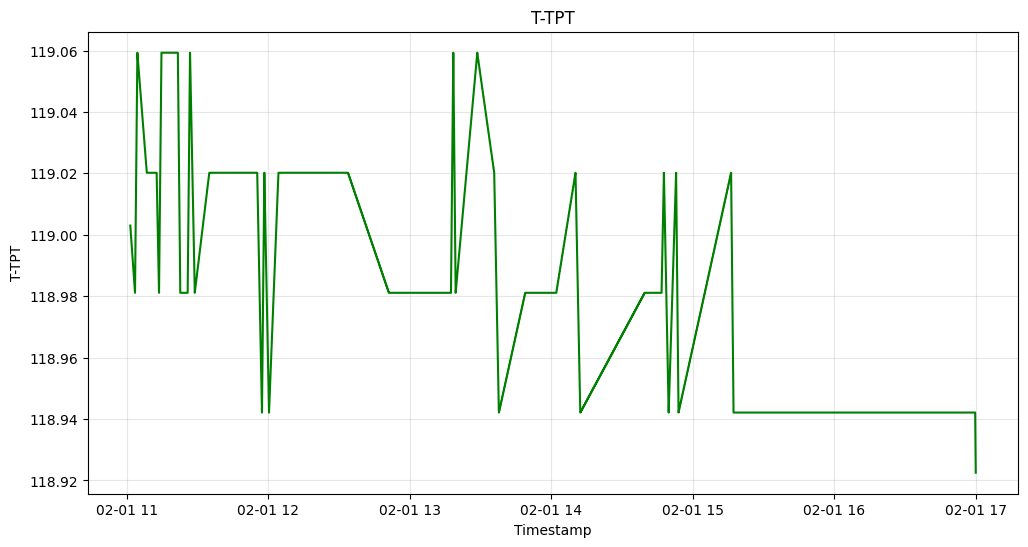

In [52]:
series = sig["T-TPT"]

fig, path = DataVisualization.plot_series(
    series=series,
    title="T-TPT",
    xlabel="Timestamp",
    ylabel="T-TPT",
    overlay_events=False,
    color="green",
)

plt.show()


#### Multiple Series Example

The `plot_multiple_series` function allows plotting multiple signals together.

This is helpful for:

* Comparing signals
* Observing correlations visually
* Identifying synchronized patterns

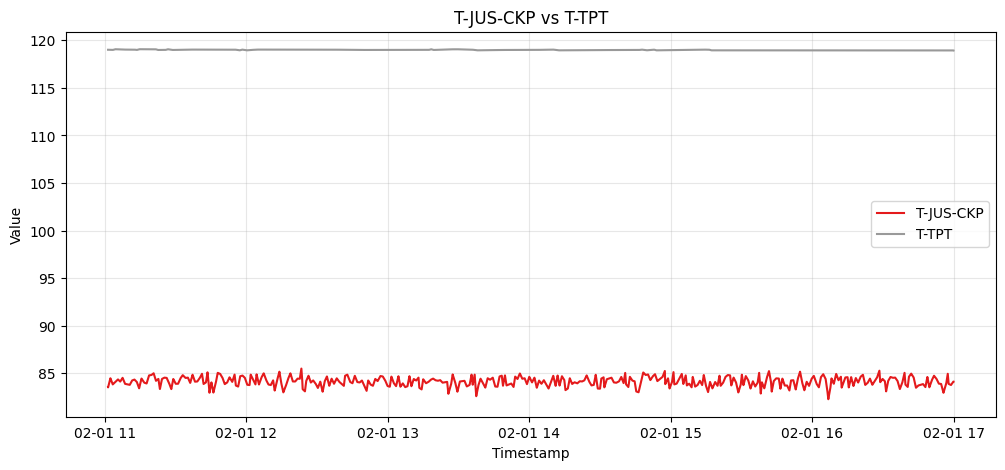

In [53]:
features = ["T-JUS-CKP", "T-TPT"]
series_list = [sig[f] for f in features]

fig, ax = plt.subplots(figsize=(12, 5))

DataVisualization.plot_multiple_series(
    series_list=series_list,
    labels=features,
    title="T-JUS-CKP vs T-TPT",
    xlabel="Timestamp",
    ylabel="Value",
    ax=ax,
)

plt.show()


#### Correlation Heatmap Example

The `correlation_heatmap` function computes and visualizes pairwise correlations between features.

This is useful for:

* Detecting redundant features
* Understanding relationships between variables
* Guiding feature selection

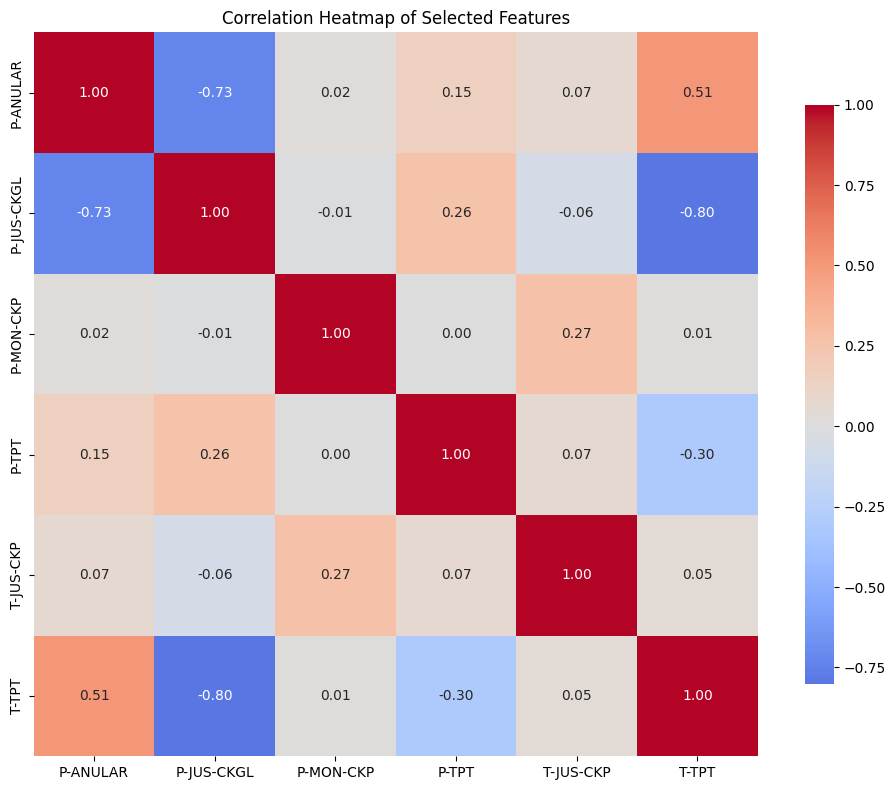

In [54]:
features = [
    "P-ANULAR",
    "P-JUS-CKGL",
    "P-MON-CKP",
    "P-TPT",
    "T-JUS-CKP",
    "T-TPT",
]

subset = sig[features]

fig = DataVisualization.correlation_heatmap(
    df_of_series=subset,
    title="Correlation Heatmap of Selected Features",
)

plt.show()

**Key Takeaways**

* Visualization helps validate preprocessing steps and understand signal behavior
* Single plots reveal individual patterns and anomalies
* Multi-series plots enable direct comparison between features
* Correlation heatmaps highlight relationships and redundancy

These tools are essential for building intuition before moving to modeling.

------

## 6.  🤖 Model Training and Evaluation <a id="model-training-and-evaluation"></a>

In this section, we demonstrate how to train and evaluate machine learning models using the 3WToolkit.

The goal is to transform raw time-series data into a structured dataset suitable for supervised learning. Each window extracted from the signal will be treated as an independent sample, with its corresponding label.

The workflow includes:

- Loading the dataset  
- Splitting into train/validation/test sets  
- Preprocessing and feature extraction  
- Training a model  
- Evaluating performance

First we import the relevant modules and initialize a ParquetDataset instance, defining the target classes 0, 1 and 2. 

#### 6.1. Dataset loading and manual split

In this example, we use only **REAL events** and manually split the dataset into training, validation, and test sets.

Since `ParquetDataset` does not provide a built-in method for splitting datasets, we perform this step manually using file lists.  
This ensures that all subsets come from the same data distribution and avoids mixing simulated and real events.

**Step 1: Load dataset**

In [55]:
RANDOM_SEED = 2026

dataset_path = "../../dataset"
classes = [0, 1, 2]

ds = ParquetDatasetConfig(
    path=dataset_path,
    event_type=["real"],
    target_class=classes,
).build()

print(f"\nTotal events: {len(ds)}")

2026-04-23 00:19:33,602 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-23 00:19:33,604 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-23 00:19:33,607 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!



Total events: 620


**Step 2: Shuffle and split indices**

We randomly shuffle the dataset and split it into:

* **70% training**
* **15% validation**
* **15% testing**


In [56]:
np.random.seed(RANDOM_SEED)

all_files = ds.files_events

indices = np.arange(len(all_files))
np.random.shuffle(indices)

n = len(indices)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

In [57]:
print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 434, Val: 93, Test: 93


**Step 3: Create file lists**

We map the indices back to the corresponding dataset files:

In [58]:
train_files = [all_files[i] for i in train_idx]
val_files = [all_files[i] for i in val_idx]
test_files = [all_files[i] for i in test_idx]

**Step 4: Create dataset splits**

We now create new dataset instances using the `split="list"` option:

In [59]:
ds_train = ParquetDatasetConfig(
    path=dataset_path,
    split="list",
    file_list=train_files,
).build()

ds_val = ParquetDatasetConfig(
    path=dataset_path,
    split="list",
    file_list=val_files,
).build()

ds_test = ParquetDatasetConfig(
    path=dataset_path,
    split="list",
    file_list=test_files,
).build()

2026-04-23 00:19:34,343 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-23 00:19:34,345 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-23 00:19:34,358 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-23 00:19:34,756 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-23 00:19:34,758 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-23 00:19:34,764 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-23 00:19:35,118 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-23 00:19:35,120 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-23 00:19:35,124 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


> **Important:** The split is performed at the **event level (file level)**, not at the window level.

> This avoids data leakage, ensuring that windows from the same event do not appear in both training and testing sets.

This manual splitting approach provides full control over dataset partitioning and ensures reproducibility of experiments.

### 6.2. Preprocessing and feature extraction

Next, we define a pipeline that prepares the data before training.

This pipeline performs:

* Signal cleaning
* Missing value handling
* Normalization
* Label processing
* Feature extraction

In [60]:
window_size = 128

dataset_processor = TransformConfig(
    pre_processing=SequentialPreprocessingAdapterConfig(
        steps=[
            CleanSignalsConfig(missing_columns_threshold=0.65),
            ImputeMissingConfig(),
            NormalizeConfig(),
            FillLabelsConfig(),
            RemapClassConfig(),
        ]
    ),
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(window_size=window_size),
            ConcatFeatureAdapterConfig(
                steps=[
                    StatisticalConfig(),
                    EWStatisticalConfig(),
                    WaveletConfig(),
                ]
            ),
        ]
    ),
).build()

We first **fit** the pipeline on the training data, and then apply it to all splits:

In [61]:
dataset_processor.fit(ds_train)

ds_train_transformed = dataset_processor.transform(ds_train)
ds_val_transformed = dataset_processor.transform(ds_val)
ds_test_transformed = dataset_processor.transform(ds_test)

> **Important:** The pipeline is fitted only on the training set to avoid data leakage.

### 6.3. Model configuration

We define the model architecture and training parameters.

In this example, we use a simple **Multi-Layer Perceptron (MLP)**:

With the ParquetDataset instance defined, we can set the parameters for the MLP model using the MLPConfig object. These parameters will be combined with the TrainerConfig and managed through the ModelTrainer, which encapsulates the training workflow.

The defined worflow control most relevant parameters that will be used for training of a model. 

Finally, the ModelTrainer is instantiated with the training configuration, while the ModelAssessment object prepares the evaluation pipeline. The model architecture can be visualized by printing the `trainer.model`.

In [62]:
mlp_config = MLPConfig(
    hidden_sizes=(32, 16),
    output_size=dataset_processor.num_classes,
)

trainer = TorchTrainerConfig(
    seed=RANDOM_SEED,
    config_model=mlp_config,
    learning_rate=0.0001,
    batch_size=32,
    epochs=30,
).build()

2026-04-23 00:21:17,713 | INFO | ThreeWToolkit.core.base_trainer | Initialized TorchTrainer with seed=2026
2026-04-23 00:21:17,717 | INFO | ThreeWToolkit.trainer.torch_trainer | TorchTrainer initialized | device=cpu | epochs=30 | batch_size=32


* `hidden_sizes`: number of neurons in each hidden layer
* `output_size`: number of classes
* `learning_rate`: optimizer step size
* `batch_size`: number of samples per batch
* `epochs`: number of training iterations

### 6.4. Training

We now train the model using the training and validation datasets:

In [63]:
train_results = trainer.train(
    train_dataset=ds_train_transformed,
    val_dataset=ds_val_transformed,
)

2026-04-23 00:21:17,735 | INFO | ThreeWToolkit.core.base_trainer | Starting training | train_size=434 | val_size=93
2026-04-23 00:21:17,960 | INFO | ThreeWToolkit.core.base_trainer | Dataset validation passed
2026-04-23 00:21:17,961 | INFO | ThreeWToolkit.core.base_trainer | Preparing training data...
2026-04-23 00:21:17,962 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=434)
2026-04-23 00:22:12,292 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=2201
2026-04-23 00:22:12,295 | INFO | ThreeWToolkit.core.base_trainer | Preparing validation data...
2026-04-23 00:22:12,297 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=93)
2026-04-23 00:22:23,125 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=459
2026-04-23 00:22:23,129 | INFO | ThreeWToolkit.core.base_trainer | Initializing training state...
2026-04-23 00:22:23,134 | INFO | ThreeWToolkit.trainer.torch_trai

Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

2026-04-23 00:24:44,936 | INFO | ThreeWToolkit.core.base_trainer | Training completed successfully


During training, the model learns to map feature vectors (windows) to their corresponding labels.

### 6.5. Evaluation

After training, we evaluate the model on the test set:

In [64]:
test_predictions = trainer.predict(ds_test_transformed)

assessment = ModelAssessmentConfig(
    metrics=["accuracy"],
).build()

results = assessment.evaluate(
    training_results=train_results,
    predictions=test_predictions,
)

2026-04-23 00:24:44,977 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=93)
2026-04-23 00:24:55,449 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=446
2026-04-23 00:24:55,752 | INFO | ThreeWToolkit.assessment.model_assess | Results exported to /usr/local/lib/python3.10/site-packages/output/exp_20260423_0024
2026-04-23 00:24:55,754 | INFO | ThreeWToolkit.assessment.model_assess | Model Assessment Summary
Model: MLP
Task Type: classification
Timestamp: 20260423_0024

Metrics:
  accuracy: 0.9807

Training History:
  Final train_loss: 0.0276
  Final val_loss: 0.0278


In [65]:
print("Evaluation results:", results)

Evaluation results: model=MLP(
  (activation_func): ReLU()
  (model): Sequential(
    (0): Linear(in_features=448, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=5, bias=True)
  )
) task_type=<TaskTypeEnum.CLASSIFICATION: 'classification'> timestamp='20260423_0024' true_values=array([0, 0, 0, ..., 0, 0, 0], shape=(14248,)) predictions=array([0, 0, 0, ..., 0, 0, 0], shape=(14248,)) metrics={'accuracy': 0.9806990454800674} training_history=TrainingHistory(train_loss=[0.2539074626204975, 0.05411567642623859, 0.04366377206476509, 0.03848996121321159, 0.035128252348050275, 0.03308121912151731, 0.03179874249208846, 0.030967690770290365, 0.030672086095358864, 0.03013344915780842, 0.029906109071567315, 0.02944166866618674, 0.029495722561104484, 0.029399879737166085, 0.029146666773129846, 0.028917282769989762, 0.028859082839464943, 0.02870138349163847, 0.02861531243746622, 0.028

This step computes quantitative metrics such as accuracy.

### 6.7. Training history visualization

The trainer object also collects a history of validation and training loss that can be visualized after the training is completed. 

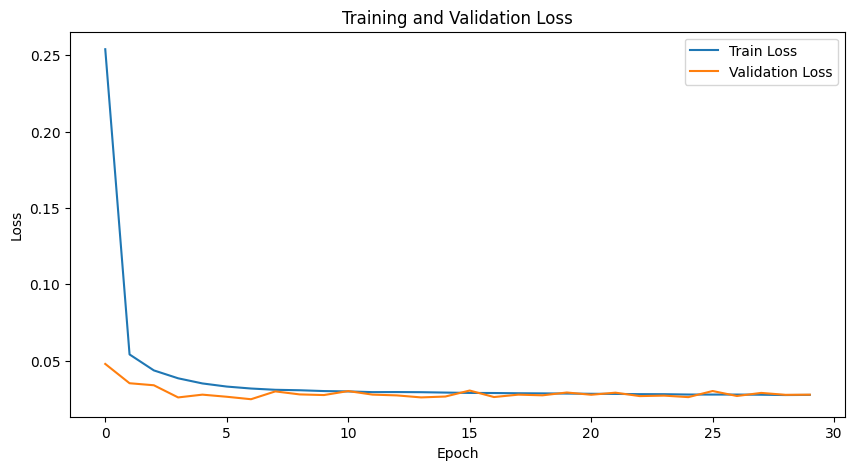

In [66]:
history = train_results.history

plt.figure(figsize=(10, 5))
plt.plot(history.train_loss, label="Train Loss")
plt.plot(history.val_loss, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

This plot helps identify:

* Overfitting (validation loss increases)
* Underfitting (both losses high)
* Convergence behavior


**Key Takeaways**

* Use **only REAL data** for consistent evaluation
* Always split data **before preprocessing**
* Fit pipelines **only on training data**
* Combine multiple feature extractors for richer representations
* Monitor training curves to diagnose model behavior

## 7. 🔗 Pipeline Integration <a id="pipeline-integration"></a>

The `Pipeline` class provides a structured way to combine all steps of the machine learning workflow into a single, cohesive process.

Using pipelines:
- Reduces boilerplate code  
- Ensures reproducibility  
- Simplifies experimentation with different configurations  
- Guarantees consistent data flow between steps  

________

### Pipeline Execution Flow

The pipeline follows a sequential execution model:

```text
Dataset → Preprocessing → Feature Extraction → Training → Evaluation
````

Each step is configured using its corresponding configuration class, allowing modular and flexible design.

______

### 7.1 Creating a Basic Pipeline

First, we import the required modules:

In [67]:
import matplotlib.pyplot as plt

from ThreeWToolkit.pipeline import PipelineConfig
from ThreeWToolkit.dataset import ParquetDatasetConfig, TransformConfig
from ThreeWToolkit.preprocessing import (
    SequentialPreprocessingAdapterConfig,
    CleanSignalsConfig,
    FillLabelsConfig,
    RemapClassConfig,
    NormalizeConfig,
    ImputeMissingConfig,
)
from ThreeWToolkit.feature_extraction import (
    WindowingConfig,
    SequentialFeatureAdapterConfig,
    ConcatFeatureAdapterConfig,
    StatisticalConfig,
    EWStatisticalConfig,
    WaveletConfig,
)
from ThreeWToolkit.models import MLPConfig
from ThreeWToolkit.trainer import TorchTrainerConfig
from ThreeWToolkit.assessment import ModelAssessmentConfig

#### ⚠️ Important note on dataset splitting

The `Pipeline` API currently expects dataset configurations rather than pre-split datasets.
Therefore, it does **not directly support custom manual splits** like the one implemented in Section 6.

For this example, we use different `event_type` values as a proxy split.
However, for rigorous experiments, prefer the **manual split approach shown previously**.

### 7.2. Defining the pipeline

In [68]:
path = "../../dataset"
pipeline = PipelineConfig(
    train_dataset_config=ParquetDatasetConfig(
        path=path,
        version="2.0.0",
        target_column="class",
        target_class=[1, 2],
        force_download=False,
        event_type=["real"],
    ),
    test_dataset_config=ParquetDatasetConfig(
        path=path,
        version="2.0.0",
        target_column="class",
        target_class=[1, 2],
        force_download=False,
        event_type=["drawn"],
    ),
    trainer_config=TorchTrainerConfig(
        config_model=MLPConfig(
            hidden_sizes=(64, 32),
            output_size=5,
        ),
        seed=42,
        epochs=50,
        batch_size=32,
        learning_rate=1e-4,
        device="cpu",
    ),
    pre_transform_config=TransformConfig(
        pre_processing=SequentialPreprocessingAdapterConfig(
            steps=[
                CleanSignalsConfig(missing_column_threshold=0.65),
                FillLabelsConfig(),
                RemapClassConfig(),
            ],
        )
    ),
    transform_config=TransformConfig(
        pre_processing=SequentialPreprocessingAdapterConfig(
            steps=[
                NormalizeConfig(),
                ImputeMissingConfig(),
            ]
        ),
        feature_extraction=SequentialFeatureAdapterConfig(
            steps=[
                WindowingConfig(),
                ConcatFeatureAdapterConfig(
                    steps=[
                        StatisticalConfig(),
                        EWStatisticalConfig(),
                        WaveletConfig(),
                    ]
                ),
            ]
        ),
    ),
).build()

2026-04-23 00:24:56,376 | INFO | ThreeWToolkit.core.base_trainer | Initialized TorchTrainer with seed=42
2026-04-23 00:24:56,378 | INFO | ThreeWToolkit.trainer.torch_trainer | TorchTrainer initialized | device=cpu | epochs=50 | batch_size=32
2026-04-23 00:24:56,641 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-23 00:24:56,645 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-23 00:24:56,651 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-23 00:24:57,127 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-23 00:24:57,128 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-23 00:24:57,132 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-23 00:24:57,317 | INFO | ThreeWToolkit.pipeline | Pipeline initialized | experiment=experiment


### 7.3. Running the pipeline

In [69]:
results = pipeline.run()

2026-04-23 00:24:57,394 | INFO | ThreeWToolkit.pipeline | Starting pipeline execution
2026-04-23 00:24:57,399 | INFO | ThreeWToolkit.pipeline | Fitting preprocessing transform on training data...
2026-04-23 00:25:01,087 | INFO | ThreeWToolkit.pipeline | Applying preprocessing transform to training data...
2026-04-23 00:25:01,089 | INFO | ThreeWToolkit.pipeline | Applying preprocessing transform to test data...
2026-04-23 00:25:01,091 | INFO | ThreeWToolkit.pipeline | Fitting transform on training data...
2026-04-23 00:25:03,632 | INFO | ThreeWToolkit.pipeline | Training model...
2026-04-23 00:25:03,634 | INFO | ThreeWToolkit.core.base_trainer | Starting training | train_size=26 | val_size=None
2026-04-23 00:25:03,814 | INFO | ThreeWToolkit.core.base_trainer | Dataset validation passed
2026-04-23 00:25:03,816 | INFO | ThreeWToolkit.core.base_trainer | Preparing training data...
2026-04-23 00:25:03,817 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

2026-04-23 00:25:22,957 | INFO | ThreeWToolkit.core.base_trainer | Training completed successfully
2026-04-23 00:25:22,960 | INFO | ThreeWToolkit.pipeline | Training complete
2026-04-23 00:25:22,962 | INFO | ThreeWToolkit.pipeline | Training completed
2026-04-23 00:25:22,964 | INFO | ThreeWToolkit.pipeline | Generating predictions...
2026-04-23 00:25:22,965 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=10)
2026-04-23 00:25:25,906 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=134
2026-04-23 00:25:26,055 | INFO | ThreeWToolkit.pipeline | Prediction complete


The pipeline automatically:

* Loads the datasets
* Applies preprocessing and feature extraction
* Trains the model
* Evaluates performance

### 7.4. Visualizing training results

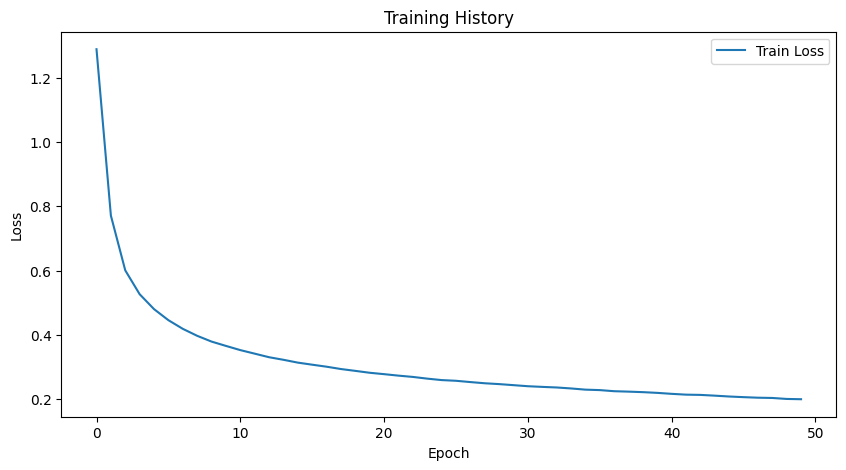

In [70]:
history = results.training_result.history

plt.figure(figsize=(10, 5))
plt.plot(history.train_loss, label="Train Loss")

plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### 7.5. Example pipeline configurations

One of the main advantages of pipelines is the ability to easily modify configurations.

**Minimal pipeline (fast experimentation)**

<div style="font-size:15px">

```python id="pipe_min"
transform_config = TransformConfig(
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(window_size=64),
            StatisticalConfig(features=["mean", "std"]),
        ]
    )
)
```

**Full feature pipeline (richer representation)**

```python id="pipe_full"
transform_config = TransformConfig(
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(window_size=128),
            ConcatFeatureAdapterConfig(
                steps=[
                    StatisticalConfig(),
                    EWStatisticalConfig(),
                    WaveletConfig(),
                ]
            ),
        ]
    )
)
```

### 7.6. Best Practices

* Always **fit preprocessing on training data only**
* Avoid mixing **real and simulated data** unless intentional
* Use **windowing before feature extraction** (mandatory)
* Start with simple features, then increase complexity
* Monitor training curves to detect overfitting
* Ensure splits are done at the **event level**, not window level

**Key Takeaways**

* Pipelines unify the entire ML workflow into a single object
* They improve reproducibility and maintainability
* They are ideal for experimentation and benchmarking
* Manual dataset splitting (Section 6) is still recommended for rigorous evaluation

**Reproducibility**

Always set random seeds for reproducibility:

<div style="font-size:15px">

```python
TorchTrainerConfig(seed=42, ...)

**Experiment Tracking**

Enable result export to keep track of your experiments:

<div style="font-size:15px">

```python
ModelAssessmentConfig(
    export_results=True,
    generate_report=True  # For detailed analysis
)

__________

## 8. 📄 Report Generation <a id="report-generation"></a>



After training and evaluating a model, it is essential to **document and communicate the results** in a clear and reproducible way.

The `3WToolkit` provides a `ReportGeneration` module that automatically creates structured reports in **HTML** or **LaTeX** format.  
This allows you to consolidate model performance, dataset information, and visualizations into a single, shareable artifact.

A generated report typically includes:

- **Model information** (architecture and configuration)  
- **Dataset summary** (training and testing data)  
- **Performance metrics** (accuracy, precision, recall, F1-score)  
- **Confusion matrix**  
- **Classification report** (per-class breakdown)  
- **Custom visualizations**  


We will now generate a report using the model and results obtained in Section 6.

First, import the report module:

In [71]:
from ThreeWToolkit.reports.report_generation import ReportGeneration

**Step 1: Preparing inputs**

The report now requires only:

* Number of training samples
* Number of testing samples
* Model predictions
* Evaluation metrics

We assume that the datasets `ds_train_transformed` and `ds_test_transformed`
were created in Section 6 using the preprocessing and feature extraction pipeline.
These datasets contain the transformed features used for training and evaluation.

In [72]:
train_len = sum(len(event.signal) for event in ds_train_transformed)
test_len = sum(len(event.signal) for event in ds_test_transformed)

predictions = trainer.predict(ds_test_transformed)

2026-04-23 00:26:17,710 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=93)
2026-04-23 00:26:28,530 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=446


> Instead of passing full datasets, we summarize them using their sizes.

> This reduces memory usage and simplifies report generation.

**Step 2: Computing evaluation metrics**

In [73]:
assessment = ModelAssessmentConfig(
    metrics=["accuracy", "precision", "recall", "f1"],
).build()

metrics_to_include = assessment.evaluate(
    training_results=train_results,
    predictions=predictions,
)

2026-04-23 00:26:28,924 | INFO | ThreeWToolkit.assessment.model_assess | Results exported to /usr/local/lib/python3.10/site-packages/output/exp_20260423_0026
2026-04-23 00:26:28,926 | INFO | ThreeWToolkit.assessment.model_assess | Model Assessment Summary
Model: MLP
Task Type: classification
Timestamp: 20260423_0026

Metrics:
  accuracy: 0.9807
  precision: 0.9705
  recall: 0.9807
  f1: 0.9754

Training History:
  Final train_loss: 0.0276
  Final val_loss: 0.0278


These metrics will be directly included in the report.

**Step 3: Adding custom visualizations (optional)**

Custom plots can still be included:

In [74]:
sig = ds_test[0].signal.copy()

plot_config = {
    "PlotSeries": {
        "series": sig["T-TPT"],
        "title": "T-TPT",
        "xlabel": "Timestamp",
        "ylabel": "T-TPT",
        "overlay_events": False,
    },
    "PlotMultipleSeries": {
        "series_list": [sig["P-MON-CKP"], sig["P-TPT"]],
        "labels": ["P-MON-CKP", "P-TPT"],
        "title": "Pressure Signals",
        "xlabel": "Timestamp",
        "ylabel": "Value",
    },
    "PlotCorrelationHeatmap": {
        "df_of_series": sig[
            ["P-ANULAR", "P-JUS-CKGL", "P-MON-CKP", "P-TPT", "T-JUS-CKP", "T-TPT"]
        ],
        "title": "Correlation Heatmap",
    },
}

**Step 4: Creating the report**

In [85]:
metrics_to_include.metrics

{'accuracy': 0.9806990454800674,
 'precision': 0.9704873370830753,
 'recall': 0.9806990454800674,
 'f1': 0.975357691575176}

In [86]:
report_generation = ReportGeneration(
    model=trainer.model,
    train_len=train_len,
    test_len=test_len,
    predictions=predictions,
    calculated_metrics=metrics_to_include.metrics,
    plot_config=plot_config,
    title="3WToolkit Signal Analysis Report",
    author="Your Name",
    export_report_after_generate=False,
)

**Step 5: Exporting the report**

In [88]:
html_report = report_generation.generate_summary_report(
    template_name="report_template.html",
    format="html",
)

latex_report = report_generation.generate_summary_report(format="latex")

report_generation.save_report(
    html_report, "signal_analysis_report", format="html"
)

report_generation.save_report(
    latex_report, "signal_analysis_report", format="latex"
)

2026-04-23 01:06:23,078 | INFO | ThreeWToolkit.reports.report_generation | Generating HTML report from template: 'report_template.html'...
2026-04-23 01:06:25,421 | INFO | ThreeWToolkit.reports.report_generation | Markdown report generated successfully.
2026-04-23 01:06:25,423 | INFO | ThreeWToolkit.reports.report_generation | Generating Beamer report: '3WToolkit Signal Analysis Report'...
2026-04-23 01:06:25,958 | INFO | ThreeWToolkit.reports.report_generation | Beamer document generated successfully.
2026-04-23 01:06:25,960 | INFO | ThreeWToolkit.reports.report_generation | Saving HTML report to '/usr/local/lib/python3.10/site-packages/ThreeWToolkit/reports/report-3WToolkit Signal Analysis Report/html/signal_analysis_report.html'...
2026-04-23 01:06:25,961 | INFO | ThreeWToolkit.reports.report_generation | HTML report saved successfully to '/usr/local/lib/python3.10/site-packages/ThreeWToolkit/reports/report-3WToolkit Signal Analysis Report/html/signal_analysis_report.html'
2026-04-2

* **HTML** → ideal for visualization and sharing
* **LaTeX** → ideal for academic and technical reports

**Key Takeaways**

* The report generator now works with **summarized inputs**
* It focuses on **predictions and metrics**, not raw datasets
* It simplifies integration into ML pipelines
* Custom plots enhance interpretability


In [78]:
from pathlib import Path

p = Path("/usr/local/lib/python3.10/site-packages/ThreeWToolkit/reports/html")
print(p.exists())
print(list(p.glob("*")))

True
[PosixPath('/usr/local/lib/python3.10/site-packages/ThreeWToolkit/reports/html/report_template.html')]


_________

This completes the full machine learning workflow using the 3WToolkit.